# Python script for descriptive statisics, Chi-Square analysis on non-visibility, and figure creation for instantaneous observations of Afruca tangeri in two crabitats (110 tank & tub) at the Sainsbury Wellcome Centre for Neural Circuits and Animal Behaviour throughout 2022-2023. 
## Composed by Sanna Titus | sannatitus@gmail.com | 25 May 2025

# Data preparation

In [45]:
import os
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates 
import seaborn as sns
import networkx as nx
import matplotlib.lines as mlines
import matplotlib.patheffects as path_effects
from scipy.stats import chi2_contingency
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from datetime import datetime
from matplotlib.dates import date2num
from matplotlib.colors import LogNorm
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score

file_path = 'https://github.com/sannatitus/Afruca-tangeri_captive-behaviour/raw/main/Data/instantaneous-behaviour-raw-data.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', engine='openpyxl') #'openpyxl' engine is necessary for .xlsb 

save_path = '/Users/sanna/Desktop/figs/' #all contents have been uploaded to subfolder 'https://github.com/sannatitus/Afruca-tangeri_captive-behaviour/raw/main/Figures+Results'

# Data exploration
Observations + crab IDs

Population + sex ratio IQR 

Confirmed + minimum lifespan 

Confirmed + minimum lifespan figure

Chi squared results for influencing NV

In [46]:
# Creating dataframes for the observed crabs (df_active) and total observation opportunities (df_total) 

## Quick df formatting
#df['real time'] = pd.to_datetime(df['real time'], format='%H:%M:%S')

## Active crabs - requires drop of video dates where no crabs were observed 
df_active = df[df['crab ID'] != 'NV'].copy()
active_observation_windows = df[['video file', 'selected observation period start', 'crab ID']].drop_duplicates()
active_observation_windows = active_observation_windows.shape[0]
active_observation_windows_percrabitat = df[['crabitat', 'video file', 'selected observation period start', 'crab ID']].drop_duplicates()
active_observation_windows_percrabitat = active_observation_windows_percrabitat.groupby('crabitat').size().reset_index(name='unique observation windows')

## Total (and per crabitat) observation hours & present crabs
unique_observation_windows = df.groupby(["crabitat", "video file", "selected observation period start"]).size().reset_index(name='unique observation windows')
observations_per_crabitat = unique_observation_windows.groupby("crabitat").size()
observation_window_hours = (observations_per_crabitat * 30) / 60  
total_observation_hours = observation_window_hours.sum() 
print("Total observation hours per crabitat:")
print(observation_window_hours.to_string())
print(f"\nTotal observation hours across all crabitats: {total_observation_hours:.1f} hours")
print(f"Quantity of unique observation windows: {(active_observation_windows)}") 
print(f"Quantity of observation windows per crabitat: {(active_observation_windows_percrabitat)}") 
print(f"Quantity of observed individual instantaneous behaviours: {len(df_active)}")

## Total crabs, retrospectively adding all missing individuals as NV_sexnumber. In other words, NV_f1 indicates one female was present in the crabitat but not observed during this window. 
def calculate_nv_crabs(df):
    (df[df['video file'].fillna("").str.contains("tank2023-04-02T09_00_00.avi")])
    complete_data = pd.DataFrame()  # Initialize an empty DataFrame
    grouped = df.groupby(['video file', 'selected observation period start']) # used to be grouped = df.groupby(['video file', 'selected observation period start'])
    for (video_file, obs_start), group in grouped:
        present_population = group['present population'].iloc[0]
        present_males = group['present males'].iloc[0]
        present_females = group['present females'].iloc[0]
        observed_males = group.loc[group['sex'] == 'm', 'crab ID'].nunique()
        observed_females = group.loc[group['sex'] == 'f', 'crab ID'].nunique()
        num_nv_males = max(0, int(present_males - observed_males))
        num_nv_females = max(0, int(present_females - observed_females))
        nv_rows = []
        for i in range(1, num_nv_males + 1):
            for minute in range(1, 31):
                nv_rows.append({
                    'video file': video_file,
                    'crabitat': group['crabitat'].iloc[0],
                    'photoperiod': group['photoperiod'].iloc[0],
                    'day type': group['day type'].iloc[0],
                    'tide category': group['tide category'].iloc[0],
                    'tide type': group['tide type'].iloc[0],
                    'tide regime': group['tide regime'].iloc[0],
                    'present population': present_population,
                    'present sex ratio': group['present sex ratio'].iloc[0],
                    'present males': present_males,
                    'present females': present_females,
                    'selected observation period start': obs_start,
                    'real time': group['real time'].iloc[0],
                    'observation minute from start': minute,
                    'crab ID': f'NV_m{i}',
                    'sex': 'm',
                    'instantaneous behaviour': 'NV',
                    'human visible?': 'N'
                })

        for i in range(1, num_nv_females + 1):
            for minute in range(1, 31):
                nv_rows.append({
                    'video file': video_file,
                    'crabitat': group['crabitat'].iloc[0],
                    'photoperiod': group['photoperiod'].iloc[0],
                    'day type': group['day type'].iloc[0],
                    'tide category': group['tide category'].iloc[0],
                    'tide type': group['tide type'].iloc[0],
                    'tide regime': group['tide regime'].iloc[0],
                    'present population': present_population,
                    'present sex ratio': group['present sex ratio'].iloc[0],
                    'present males': present_males,
                    'present females': present_females,
                    'selected observation period start': obs_start,
                    'real time': group['real time'].iloc[0],
                    'observation minute from start': minute,
                    'crab ID': f'NV_f{i}',
                    'sex': 'f',
                    'instantaneous behaviour': 'NV',
                    'human visible?': 'N'
                })
        nv_rows_df = pd.DataFrame(nv_rows)
        full_group_data = pd.concat([group, nv_rows_df], ignore_index=True)
        expected_rows = present_population * 30
        actual_rows = full_group_data.shape[0]
        if actual_rows == expected_rows and observed_females <= present_females:
            complete_data = pd.concat([complete_data, full_group_data], ignore_index=True)
        else:
            if actual_rows != expected_rows:
                print(f"Skipping {video_file} due to row mismatch.")
        expected_nv_males = present_males - observed_males
        expected_nv_females = present_females - observed_females
    column_order = ['video file', 'crabitat', 'photoperiod', 'day type', 'tide category', 'tide type', 'tide regime', 
                    'present population', 'present sex ratio', 'present males', 'present females', 
                    'selected observation period start', 'real time', 'observation minute from start', 
                    'real time', 'observation minute from start', 'crab ID', 'sex', 'instantaneous behaviour', 'human visible?', 'arrival date', 'termination date', 'termination description', 'confirmed minimum lifespan', 'carapace length at arrival (mm)'] 

    complete_data = complete_data[column_order] 
    return complete_data
df_total = calculate_nv_crabs(df).copy()

df_total = df_total.loc[:, ~df_total.columns.duplicated()] #sorting a duplicate 'real time' column issue 
print(f"Total quantity of observation opportunities in df_total: {len(df_total)}")
#print(f"Total quantity of observation opportunities in df: {len(df)}")
percentNV = ((len(df_total) - len(df_active)) / len(df_total)) * 100
print(f"Proportion of observation opportunities where crabs were not visible: {percentNV}%")

df_active['hour_of_day'] = df_active['real time'].apply(lambda x: x.hour)
df_total['hour_of_day'] = df_total['real time'].apply(lambda x: x.hour)

### The following information was extracted from husbandry database
total_crabs_present = {
    "Date": ["23/8/22", # tank study initiation (crabs were imported before this date)
             "6/10/22",
             "20/2/23",
             "15/3/23",
             "20/4/23", 
             "26/7/23", 
             "23/4/23", # tub study initiation (crabs were imported before this date)
             "27/7/23"], 
    "Location": ["Tank"] * 6 + ["Tub"] * 2,
    "Crabs Added": [12, 10, 3, 3, 12, 9, 25, 25]
}
total_crabs_present = pd.DataFrame(total_crabs_present)
total_crabs_present = total_crabs_present["Crabs Added"].sum()
print(f"Quantity of total unique crab IDs: {total_crabs_present}")

## Comparing no of crabs present vs no of crabs observed 
active_crab_ids = df.groupby(['arrival date', 'termination date', 'termination description', 'crab ID']).nunique().reset_index()
print(f"Quantity of actively observed unqiue crab IDs: {len(active_crab_ids)}")

Total observation hours per crabitat:
crabitat
tank    80.0
tub     60.0

Total observation hours across all crabitats: 140.0 hours
Quantity of unique observation windows: 1626
Quantity of observation windows per crabitat:   crabitat  unique observation windows
0     tank                         446
1      tub                        1180
Quantity of observed individual instantaneous behaviours: 47220
Total quantity of observation opportunities in df_total: 113640
Proportion of observation opportunities where crabs were not visible: 58.447729672650475%
Quantity of total unique crab IDs: 99
Quantity of actively observed unqiue crab IDs: 98


In [47]:
# Population and sex ratio IQR
## proper handling of scenarios with 0 females, where sex ratio will just = males 
df_total['calculated sex ratio'] = np.where(
    df_total['present females'] == 0, 
    df_total['present males'], 
    np.where(df_total['present males'] == 0, 
             0,  
             df_total['present males'] / df_total['present females']) 
)

df_active['calculated sex ratio'] = np.where(
    df_active['present females'] == 0, 
    df_active['present males'], 
    np.where(df_active['present males'] == 0, 
             0,  
             df_active['present males'] / df_active['present females']) 
)

df_normalized = df_total.groupby('video file').first().reset_index()

def five_number_summary(series):
    return {
        "Min": series.min(),
        "Q1": series.quantile(0.25),
        "Median": series.median(),
        "Q3": series.quantile(0.75),
        "Max": series.max(),
    }

summary_total = {
    col: five_number_summary(df_normalized[col]) 
    for col in ['present population', 'calculated sex ratio', 'carapace length at arrival (mm)']
}

summary_by_crabitat = df_normalized.groupby('crabitat')[
    ['present population', 'calculated sex ratio']
].apply(lambda g: g.apply(five_number_summary))

print("Total dataset:")
for col, summary in summary_total.items():
    print(f"\n{col}:")
    for stat, value in summary.items():
        print(f"  {stat}: {value}")

measured_carapaces = df_total.groupby(['arrival date', 'termination date', 'termination description', 'crab ID', 'carapace length at arrival (mm)']).nunique().reset_index()
print(f"Number of crabs who had their carapace length measured upon arrival: {len(measured_carapaces)}")

print("\nBy crabitat:")
for crabitat, group_summary in summary_by_crabitat.iterrows():
    print(f"\nCrabitat: {crabitat}")
    for col in ['present population', 'calculated sex ratio']:
        print(f"  {col}:")
        for stat, value in group_summary[col].items():
            print(f"    {stat}: {value}")

Total dataset:

present population:
  Min: 2
  Q1: 6.0
  Median: 15.0
  Q3: 21.0
  Max: 25

calculated sex ratio:
  Min: 0.0
  Q1: 2.875
  Median: 4.0
  Q3: 5.3125
  Max: 9.0

carapace length at arrival (mm):
  Min: 22.19
  Q1: 23.63
  Median: 24.53
  Q3: 25.18
  Max: 26.99
Number of crabs who had their carapace length measured upon arrival: 78

By crabitat:

Crabitat: tank
  present population:
    Min: 2
    Q1: 5.0
    Median: 7.0
    Q3: 10.0
    Max: 17
  calculated sex ratio:
    Min: 0.0
    Q1: 1.5
    Median: 3.0
    Q3: 4.0
    Max: 9.0

Crabitat: tub
  present population:
    Min: 13
    Q1: 18.5
    Median: 21.0
    Q3: 23.0
    Max: 25
  calculated sex ratio:
    Min: 3.25
    Q1: 3.75
    Median: 5.25
    Q3: 6.0
    Max: 7.0


Postmortem dissection likely cause of death frequencies: termination description
euthanasia                                                      25
conspecific aggression                                           7
parasitic infection (acanthocephalan worm)                       1
reproductive stress                                              1
respiratory stress                                               1
unsuccessful moult                                               1
last date present in a randomly selected observation window     54
Name: crab ID, dtype: int64
Number of unique crabs with 'euthanasia' in termination description: 25
Number of unique crabs alive by the end of the study: 34
Number of unique crabs who lived > 404 days: 5
Crabs who lived beyond 404 days: [14 13 12 10 18]
Earliest date: 2022-08-23 09:00:00
Latest date: 2023-08-28 08:00:00
Total days in study: 370
Minimum Lifespan Summary: {'median': np.float64(73.0), 'min': np.float64(2.0), 'max': np.float64(405.0)

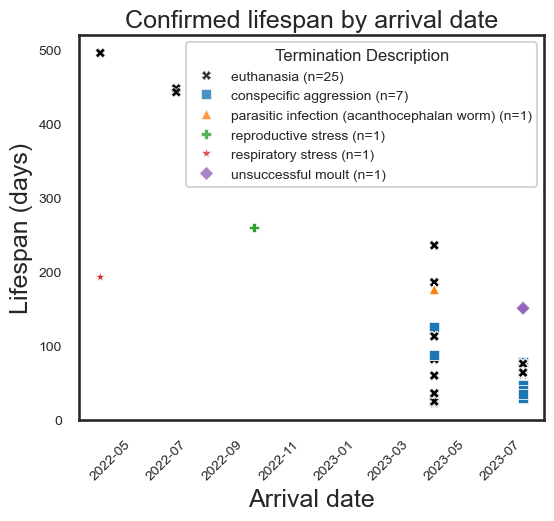

In [48]:
# Lifespan (confirmed & minimum)
## confirmed lifespan excludes anyone with a termination description of 'euthanasia' and 'last date present in a randomly selected observation window'; i.e., confirmed = post-mortemed crabs 
## minimum lifespan excludes anyone with a termination description of 'euthanasia'; i.e., minimum = post-mortemed & date last observed 
category_order = [
    'euthanasia',
    'conspecific aggression',
    'parasitic infection (acanthocephalan worm)',
    'reproductive stress',
    'respiratory stress',
    'unsuccessful moult',
    'last date present in a randomly selected observation window '
]
custom_palette = {
    'euthanasia': 'black',
    'conspecific aggression': '#1f77b4',
    'parasitic infection (acanthocephalan worm)': '#ff7f0e',
    'reproductive stress': '#2ca02c',
    'respiratory stress': '#d62728',
    'unsuccessful moult': '#9467bd',
    'last date present in a randomly selected observation window ': '#939393',
    'days left until end of study' : '#ffa5a5'
}
df['termination description'] = pd.Categorical(df['termination description'], categories=category_order, ordered=True)
confirmed_lifespan_crabs = df_active[~df_active['termination description'].isin(['euthanasia', 'last date present in a randomly selected observation window '])]
num_confirmed_lifespan_crabs = confirmed_lifespan_crabs['crab ID'].nunique()
minimum_lifespan_crabs = df_active[~df_active['termination description'].isin(['euthanasia'])]
num_minimum_crabs = minimum_lifespan_crabs['crab ID'].nunique()
euthanasia_crabs = active_crab_ids[active_crab_ids['termination description'] == 'euthanasia']
num_euthanasia_crabs = euthanasia_crabs['crab ID'].nunique()
active_crab_ids['termination date'] = pd.to_datetime(active_crab_ids['termination date'])
### crabs alive through the end of the study 
still_alive_crabs = active_crab_ids[active_crab_ids['termination date'] > '2023-08-20'] # provided 1 week of leeway for still alive crabs, with respect to previously discovered 53% random visibility probability 
num_alive_crabs = still_alive_crabs['crab ID'].nunique()
### crabs with a confirmed minimum lifespan of >300 days 
old_crabs = df_active[df_active['confirmed minimum lifespan'] > 404]
num_old_crabs = old_crabs['crab ID'].nunique()
## postmortem findings 
termination_counts_unique_crabs = (
    df_active
    .drop_duplicates(subset=['crab ID', 'termination description'])
    .groupby('termination description')['crab ID']
    .nunique()
    .reindex(category_order, fill_value=0)
)
def extract_datetime(filename):
    if filename.startswith("tank"):
        datetime_str = filename[len("tank"):].split(".avi")[0]
    elif filename.startswith("tub"):
        datetime_str = filename[len("tub"):].split(".avi")[0]
    else:
        raise ValueError(f"Unexpected filename format: {filename}")
    
    datetime_str = datetime_str.replace("T", " ").replace("_", ":")
    return datetime.strptime(datetime_str, "%Y-%m-%d %H:%M:%S")
dates = [extract_datetime(f) for f in df_total['video file']]
earliest_date = min(dates)
latest_date = max(dates)
total_days = (latest_date - earliest_date).days + 1 
print(f"Postmortem dissection likely cause of death frequencies: {termination_counts_unique_crabs}")
print(f"Number of unique crabs with 'euthanasia' in termination description: {num_euthanasia_crabs}")
print(f"Number of unique crabs alive by the end of the study: {num_alive_crabs}")
print(f"Number of unique crabs who lived > 404 days: {num_old_crabs}")
print("Crabs who lived beyond 404 days:", old_crabs['crab ID'].unique())
print(f"Earliest date: {earliest_date.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Latest date: {latest_date.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total days in study: {total_days}")
## IQR
def calculate_iqr_stats(values):
    return {
        'median': np.median(values),
        'min': np.min(values),
        'max': np.max(values),
        'Q1': np.percentile(values, 25),
        'Q3': np.percentile(values, 75)
    }
minimum_lifespan_values = minimum_lifespan_crabs['confirmed minimum lifespan'].dropna()
minimum_lifespan_stats = calculate_iqr_stats(minimum_lifespan_values)
confirmed_lifespan_values = confirmed_lifespan_crabs['confirmed minimum lifespan'].dropna()
confirmed_lifespan_stats = calculate_iqr_stats(confirmed_lifespan_values)
print("Minimum Lifespan Summary:", minimum_lifespan_stats)
print("Confirmed Lifespan Summary (crabs who underwent postmortem dissections):", confirmed_lifespan_stats)
total_lifespan_values = df_active['confirmed minimum lifespan'].dropna()
total_lifespan_stats = calculate_iqr_stats(total_lifespan_values)
print("Total Lifespan Summary (all crabs):", total_lifespan_stats)

## Lifespan figures
'''
### Confimred & minimum 
sns.set_context('paper')  
sns.set_style('whitegrid')   # consistent grid look
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 10
})

termination_counts_unique_crabs = (
    df_active
    .drop_duplicates(subset=['crab ID', 'termination description'])
    .groupby('termination description')['crab ID']
    .nunique()
    .reindex(category_order, fill_value=0)
)

# Add a legend entry for minimum lifespan (not euthanised)
legend_labels = {cat: f"{cat} (n={termination_counts_unique_crabs.get(cat, 0)})" for cat in category_order}
legend_labels['Minimum lifespan (not euthanised)'] = f"Minimum lifespan (not euthanised) (n={num_minimum_crabs})"


plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_active,
    x='arrival date',
    y='confirmed minimum lifespan',
    hue='termination description',
    style='termination description',
    palette=custom_palette,
    hue_order=category_order,
    markers={'euthanasia': 'X', 'conspecific aggression': 's', 'parasitic infection (acanthocephalan worm)': '^',
             'reproductive stress': 'P', 'respiratory stress': '*', 'unsuccessful moult': 'D',
             'last date present in a randomly selected observation window ': '.'},
    s=40, 
    alpha=0.8
)
plt.xlim([datetime.strptime("31/07/2022", "%d/%m/%Y"), datetime.strptime("30/09/2023", "%d/%m/%Y")])

target_date = datetime.strptime("30/09/2023", "%d/%m/%Y")
start_date = datetime.strptime("31/07/2022", "%d/%m/%Y")

min_date = df_active['arrival date'].min()
max_date = df_active['arrival date'].max()

start_lifespan = 500
end_lifespan = 0

start_days = (start_date - min_date).days
target_days = (target_date - min_date).days

x_values = [start_date, target_date]
y_values = [start_lifespan, end_lifespan]

plt.plot(x_values, y_values, color='#ffa5a5', linestyle='dotted', linewidth=2, label="days left until end of study")

plt.xlabel("Arrival date")
plt.ylabel("Lifespan (days)")
plt.title("Confirmed & minimum lifespan by arrival date")

handles, labels = plt.gca().get_legend_handles_labels()

for i, label in enumerate(labels):
    color = custom_palette.get(label, 'black') 
    handles[i].set_color(color)

handles, labels = plt.gca().get_legend_handles_labels()
new_labels = [legend_labels[label] if label in legend_labels else label for label in labels]
if 'Minimum lifespan (not euthanised)' not in new_labels:
    new_labels.append(legend_labels['Minimum lifespan (not euthanised)'])
plt.legend(handles, new_labels, title="Termination Description", loc='upper right')
plt.savefig(save_path + 'confirmed+minimum_lifespan.png', dpi=300, bbox_inches='tight')
plt.show()
'''
### Confirmed only
df_omitminimum = df_active[df_active['termination description'] != 'last date present in a randomly selected observation window ']

category_order2 = [
    'euthanasia',
    'conspecific aggression',
    'parasitic infection (acanthocephalan worm)',
    'reproductive stress',
    'respiratory stress',
    'unsuccessful moult',
]

custom_palette2 = {
    'euthanasia': 'black',
    'conspecific aggression': '#1f77b4',
    'parasitic infection (acanthocephalan worm)': '#ff7f0e',
    'reproductive stress': '#2ca02c',
    'respiratory stress': '#d62728',
    'unsuccessful moult': '#9467bd',
}

legend_labels = {cat: f"{cat} (n={termination_counts_unique_crabs.get(cat, 0)})" for cat in category_order2}

plt.figure(figsize=(6, 5))

sns.scatterplot(
    data=df_omitminimum,
    x='arrival date',
    y='confirmed minimum lifespan',
    hue='termination description',
    style='termination description',
    palette=custom_palette2,
    hue_order=category_order2,
    style_order=category_order2,
    markers={'euthanasia': 'X', 'conspecific aggression': 's', 'parasitic infection (acanthocephalan worm)': '^',
             'reproductive stress': 'P', 'respiratory stress': '*', 'unsuccessful moult': 'D'
#             'last date present in a randomly selected observation window ': 'o'
             },
    s=50, 
    alpha=0.8
)

plt.xlabel("Arrival date")
plt.ylabel("Lifespan (days)")
plt.title("Confirmed lifespan by arrival date")

handles, labels = plt.gca().get_legend_handles_labels()

for i, label in enumerate(labels):
    color = custom_palette.get(label, 'black') 
    handles[i].set_color(color)

handles, labels = plt.gca().get_legend_handles_labels()
new_labels = [legend_labels[label] if label in legend_labels else label for label in labels]
plt.tick_params(axis='both', which='both', labelsize=10, direction='out')
plt.xticks(rotation=45)
plt.legend(handles, new_labels, title="Termination Description", loc='upper right', fontsize=10, title_fontsize=12)
plt.savefig(save_path + 'SFig2_confirmed_lifespan.png', dpi=300, bbox_inches='tight')
plt.show()

In [49]:
# Chi square on the probability of observation 
## Variables for analysis 
variables = [
    'crabitat', 
    'photoperiod', 
    'day type', 
    'tide category',
    'tide type',
    'tide regime', 
    'present population', 
    'present males',
    'present females',
    'sex',
    'human visible?',
    'calculated sex ratio',
    'hour_of_day'
]
results = {}
for var in variables:
    total_observations = df_total.groupby(var)['instantaneous behaviour'].count()
    nv_observations = df_total[df_total['instantaneous behaviour'] == 'NV'].groupby(var)['instantaneous behaviour'].count()
    grouped_data = total_observations.to_frame(name="total_observations").merge(
        nv_observations.to_frame(name="nv_observations"), 
        left_index=True, 
        right_index=True, 
        how="left"
    ).fillna(0).reset_index()
    grouped_data["nv_probability"] = grouped_data["nv_observations"] / grouped_data["total_observations"]
    results[var] = grouped_data
#    print(f'\nNV Observations for {var}:')
#    print(grouped_data[['total_observations', 'nv_observations']]) 
    contingency_table = pd.crosstab(df_total[var], df_total['instantaneous behaviour'] == 'NV') 
    print(f'Contingency Table for {var}:\n{contingency_table}\n')
    chi2, p, _, _ = chi2_contingency(contingency_table)
    print(f'Chi-squared Test for {var}:')
    print(f'Chi2 Statistic: {chi2:.2f}, p-value: {p}')
    if p < 0.05:
        print("The result is statistically significant (p < 0.05).")
    else:
        print("The result is not statistically significant (p >= 0.05).")
    results[var] = grouped_data
significant_columns = variables
def cramers_v(chi2, n, min_dim):
    return np.sqrt(chi2 / (n * (min_dim - 1)))
cramers_v_values = {}
for var in significant_columns:
    contingency_table = pd.crosstab(df_total[var], df_total['instantaneous behaviour'] == 'NV')
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    if p < 0.05:
        n = contingency_table.sum().sum()  # Total number of observations
        min_dim = min(contingency_table.shape)  # Minimum dimension of the table
        cramers_v_value = cramers_v(chi2, n, min_dim)
        cramers_v_values[var] = cramers_v_value
sorted_cramers_v = sorted(cramers_v_values.items(), key=lambda item: item[1], reverse=True)
chi_square_stats = {}
for var in significant_columns:
    contingency_table = pd.crosstab(df_total[var], df_total['instantaneous behaviour'] == 'NV')
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    if p < 0.05:
        n = contingency_table.sum().sum()
        min_dim = min(contingency_table.shape)
        cramers_v_value = cramers_v(chi2, n, min_dim)
        cramers_v_values[var] = cramers_v_value
        chi_square_stats[var] = (chi2, dof, p)
sorted_results = sorted(cramers_v_values.items(), key=lambda item: item[1], reverse=True)
print("\nVariables ordered by strength of effect (Cramér’s V):")
print(f"{'Variable':<30} {'Cramér’s V':<10} {'Chi²':<10} {'df':<5} {'p-value':<10}")
print("-" * 70)
for var, v in sorted_results:
    if var.lower().replace(" ", "_") in [x.lower().replace(" ", "_") for x in variables_to_include]:
        chi2, dof, p = chi_square_stats[var]
        print(f"{var:<30} {v:<10.4f} {chi2:<10.2f} {dof:<5} {p:<10.2e}")

variables_to_include = [
    'present population',
    'photoperiod',
    'day type',
    'hour_of_day',
    'tide type',
    'sex',
    'human visible?',
    'calculated sex ratio',
    'crabitat'
]

summary_rows = []
for var, v in sorted_results:
    if var.lower().replace(" ", "_") in [x.lower().replace(" ", "_") for x in variables_to_include]:
        chi2, dof, p = chi_square_stats[var]
        summary_rows.append({
            "Variable": var,
            "Cramers_V": round(v, 4),
            "Chi2": round(chi2, 2),
            "df": dof,
            "p_value": p
        })
summary_df = pd.DataFrame(summary_rows)

summary_df.to_csv("STable3_NV.txt", sep="\t", index=False)

Contingency Table for crabitat:
instantaneous behaviour  False  True 
crabitat                             
tank                     11820  26940
tub                      35400  39480

Chi-squared Test for crabitat:
Chi2 Statistic: 2960.42, p-value: 0.0
The result is statistically significant (p < 0.05).
Contingency Table for photoperiod:
instantaneous behaviour  False  True 
photoperiod                          
Fall                     23250  15150
Spring                    9210  26310
Summer                   13770  20190
Winter                     990   4770

Chi-squared Test for photoperiod:
Chi2 Statistic: 10696.57, p-value: 0.0
The result is statistically significant (p < 0.05).
Contingency Table for day type:
instantaneous behaviour  False  True 
day type                             
MondayWednesdayFriday        0   3750
TuesdayThursday              0   1860
Weekend                      0   2820
husbandry weekday        23610  30480
non-husbandry weekday     9540  10560
weekend

# Figure preparation 
From here, we exclude bubbling (33 obs), putative sleep (30 obs), tapping (27 obs), moulting (16 obs), mating (9 obs), waving (which was observed, but just not at the minute-specific observation intervals) 

This section maps behaviour categories and colours to each instantaneous behaviour

In [50]:
# Qualitative description of observed instantaneous behaviours, to identify those we will focus on
df_active['instantaneous behaviour'].value_counts()
## The following instantaneous behaviours were rarely observed and thus will quantitatively described rather than formally including them in subsequent analysis + figures: bubbling (33), putative sleep (30), tapping (27), moulting (16), mating (9), waving (which was observed, but just not at the minute-specific observation intervals) 

instantaneous behaviour
submerged             13059
shoreline resting      9251
mudbank resting        8245
burrowing              4744
foraging               3998
protecting burrow      2405
walking                2341
entering seawater       776
vertical extension      531
exiting seawater        497
maintaining burrow      348
threat encounter        312
entering burrow         238
exiting burrow          147
defending burrow        114
attacking burrow         99
bubbling                 33
putative sleep           30
tapping                  27
moulting                 16
mating                    9
Name: count, dtype: int64

In [51]:
# Mapping instantaneous behaviours to higher-level behavioural categories (setting variables for subsequent figures) 

instant_order = [
    'foraging',
    'walking', 'entering seawater', 'exiting seawater', 'vertical extension',
    'maintaining burrow', 'entering burrow', 'exiting burrow', 'protecting burrow',
    'attacking burrow', 'defending burrow', 'threat encounter',
    #'mating', 'tapping', 'waving',
    # 'moulting', 'bubbling', 'putative sleep',
    'shoreline resting', 'mudbank resting',
    'submerged', 
    'burrowing',
    'NV'
]

active_instant_order = [
    'foraging',
    'walking', 'entering seawater', 'exiting seawater', 'vertical extension',
    'maintaining burrow', 'entering burrow', 'exiting burrow', 'protecting burrow',
    'attacking burrow', 'defending burrow', 'threat encounter',
    #'mating', 'tapping', 'waving',
    # 'moulting', 'bubbling', 'putative sleep',
    'shoreline resting', 'mudbank resting',
    'submerged', 
    'burrowing',
]

behaviour_category = {
    'foraging': 'foraging',
    'walking': 'locomotion',
    'entering seawater': 'locomotion',
    'exiting seawater': 'locomotion',
    'vertical extension': 'locomotion',
    'attacking burrow': 'conspecific contact',
    'defending burrow': 'conspecific contact',
    'threat encounter': 'conspecific contact',
    #'mating': 'conspecific contact',
    'maintaining burrow': 'burrow activity',
    'entering burrow': 'burrow activity',
    'exiting burrow': 'burrow activity',
    'protecting burrow': 'burrow activity',
    #'tapping': 'conspecific communication', 
    #'waving': 'conspecific communication',
    #'moulting': 'resting', 
    'shoreline resting': 'resting',
    'mudbank resting': 'resting',
    'submerged': 'submerged',
    #'bubbling': 'resting',
    'burrowing': 'burrowing', 
    #'putative sleep': 'resting',
    'NV': 'NV'
}

active_behaviour_category = {
    'foraging': 'foraging',
    'walking': 'locomotion',
    'entering seawater': 'locomotion',
    'exiting seawater': 'locomotion',
    'vertical extension': 'locomotion',
    'attacking burrow': 'conspecific contact',
    'defending burrow': 'conspecific contact',
    'threat encounter': 'conspecific contact',
    #'mating': 'conspecific contact',
    'maintaining burrow': 'burrow activity',
    'entering burrow': 'burrow activity',
    'exiting burrow': 'burrow activity',
    'protecting burrow': 'burrow activity',
    #'tapping': 'conspecific communication', 
    #'waving': 'conspecific communication',
    #'moulting': 'resting', 
    'shoreline resting': 'resting',
    'mudbank resting': 'resting',
    'submerged': 'submerged',
    #'bubbling': 'resting',
    'burrowing': 'burrowing', 
    #'putative sleep': 'resting',
}

behaviour_category_order = [
    'NV',
    'foraging',
    'locomotion',
    'burrow activity',
    'conspecific contact',
    'resting',
    'submerged',
    'burrowing'
]

active_behaviour_category_order = [
    'foraging',
    'locomotion',
    'burrow activity',
    'conspecific contact',
    #'conspecific communication',
    'resting',
    'submerged',
    'burrowing'
]

df_active = df_active.copy()
df_total = df_total.copy()
df_active['behaviour_category'] = df_active['instantaneous behaviour'].map(behaviour_category)
df_total['behaviour_category'] = df_total['instantaneous behaviour'].map(behaviour_category)

### assigning behavioural category colours 
category_colors = {
    'foraging': '#D32F2F',  
    'locomotion': '#FFA726',  
    'burrow activity': '#d9c438',
    'conspecific contact': '#388E3C',
    'resting': '#86c5da', #medium blue = 2196F3 
    'submerged': '#000099',  
    'burrowing': '#8200e6', #light purple = BA68C8
    'NV': '#B0BEC5' 
}

active_category_colors = {
    'foraging': '#D32F2F',  
    'locomotion': '#FFA726',  
    'burrow activity': '#d9c438',
    'conspecific contact': '#388E3C',
    'resting': '#86c5da',  
    'submerged': '#000099',  
    'burrowing': '#8200e6', 
}

facet_category_colors = {
    'foraging': '#D32F2F',  
    'locomotion': '#FFA726',  
    'burrow activity': '#d9c438',
    'conspecific contact': '#388E3C',
    'resting': '#add8e6',  
    'submerged': '#4a4aff',  
    'burrowing': '#a735ff', 
}

df_active['category_color'] = df_active['behaviour_category'].map(category_colors)
df_total['category_color'] = df_total['behaviour_category'].map(category_colors)

# Figures 

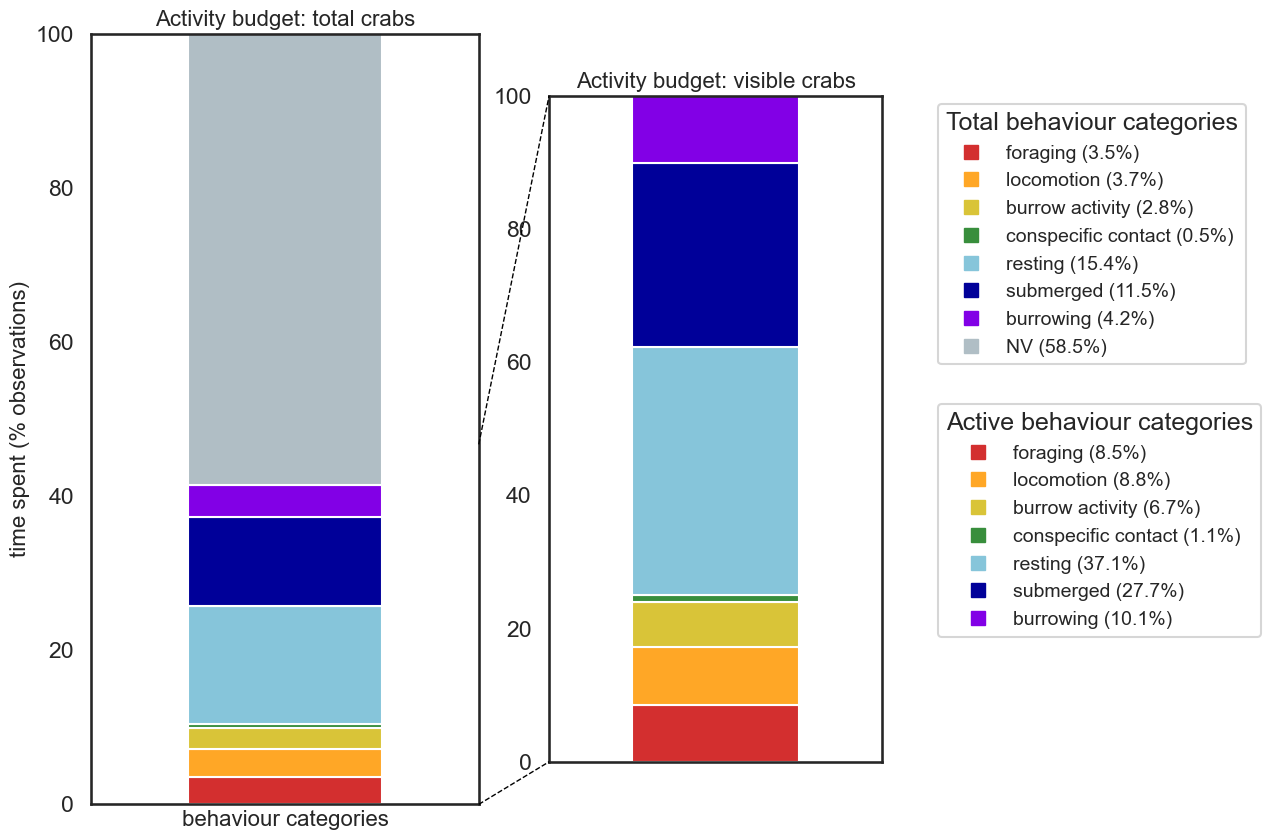

In [52]:
# Figure 1 - Activity budget stacked bar chart
## count behaviour category frequency 
category_counts = df_total['behaviour_category'].value_counts().reindex(category_colors.keys(), fill_value=0)
total_counts = category_counts.sum()
category_percentages = (category_counts / total_counts) * 100
counts_percentages_df = pd.DataFrame(category_percentages).T

category_counts_active = df_active['behaviour_category'].value_counts().reindex(category_colors.keys(), fill_value=0)
total_counts_active = category_counts_active.sum()
category_percentages_active = (category_counts_active / total_counts_active) * 100
counts_percentages_active_df = pd.DataFrame(category_percentages_active).T

category_colors_active = {k: v for k, v in category_colors.items() if k != 'NV'}

## Total crabs
fig, ax_main = plt.subplots(figsize=(5, 10))
counts_percentages_df.plot(kind='bar', stacked=True, 
                           color=[category_colors[cat] for cat in category_colors.keys()], 
                           ax=ax_main, legend=False)  # Disable automatic legend
ax_main.set_title('Activity budget: total crabs', fontsize=16)
ax_main.set_xlabel('behaviour categories', fontsize=16)
ax_main.set_ylabel('time spent (% observations)', fontsize=16)
ax_main.set_xticks([])
ax_main.set_ylim(0, 100)

## Visible (active) crabs 
ax_inset = inset_axes(ax_main, width=3.33, height=6.66, 
                      bbox_to_anchor=(2.1, 0.95), 
                      bbox_transform=ax_main.transAxes,
                      borderpad=1.0)

counts_percentages_active_df[category_colors_active.keys()].plot(
    kind='bar', stacked=True, 
    color=[category_colors_active[cat] for cat in category_colors_active.keys()], 
    ax=ax_inset, legend=False)  # Disable automatic legend
ax_inset.set_title('Activity budget: visible crabs', fontsize=16)
ax_inset.set_xticks([])
ax_inset.set_ylim(0, 100)
ax_inset.set_xlabel("")
ax_inset.set_ylabel("")

category_labels_active = list(category_colors_active.keys())
behaviour_labels_active = [f"{category} ({category_percentages_active.loc[category]:.1f}%)" for category in category_labels_active]
handles_active = [Line2D([0], [0], color=category_colors_active[category], marker='s', linestyle='None', markersize=10) for category in category_labels_active]

category_labels_total = list(category_colors.keys())
behaviour_labels_total = [f"{category} ({category_percentages.loc[category]:.1f}%)" for category in category_labels_total]
handles_total = [Line2D([0], [0], color=category_colors[category], marker='s', linestyle='None', markersize=10) for category in category_labels_total]

fig.legend(handles_active, behaviour_labels_active, title='Active behaviour categories', bbox_to_anchor=(1.8, 0.52), loc='upper left', fontsize=14)
fig.legend(handles_total, behaviour_labels_total, title='Total behaviour categories', bbox_to_anchor=(1.8, 0.82), loc='upper left', fontsize=14)

fig.canvas.draw()  

bbox_main = ax_main.get_position()
bbox_inset = ax_inset.get_position()

x_main_right = bbox_main.x1  
y_main_right = bbox_main.y0
y_main_half = bbox_main.y0 + (bbox_main.y1 - bbox_main.y0) * 0.5
x_inset_left = bbox_inset.x0
y_inset_left = bbox_inset.y0 
y_inset_top = bbox_inset.y1 

line1 = plt.Line2D([x_main_right, x_inset_left], [y_main_half - 0.025, y_inset_top], 
                   linestyle="dashed", transform=fig.transFigure, color="black", lw=1)
line2 = plt.Line2D([x_main_right, x_inset_left], [y_main_right, y_inset_left],
                   linestyle="dashed", transform=fig.transFigure, color="black", lw=1)

fig.lines.extend([line1, line2])
fig.canvas.draw()  
plt.savefig(save_path + 'Fig1_categorical-activity-budget.png', bbox_inches='tight', pad_inches=0.2, dpi=300)
plt.show()

C:\Users\Sanna\AppData\Local\Temp\ipykernel_37164\1763988093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_proportions, x='behaviour_category', y='proportion', palette=filtered_colors)
C:\Users\Sanna\AppData\Local\Temp\ipykernel_37164\1763988093.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(filtered_behaviour_category_order, rotation=45, ha='right')


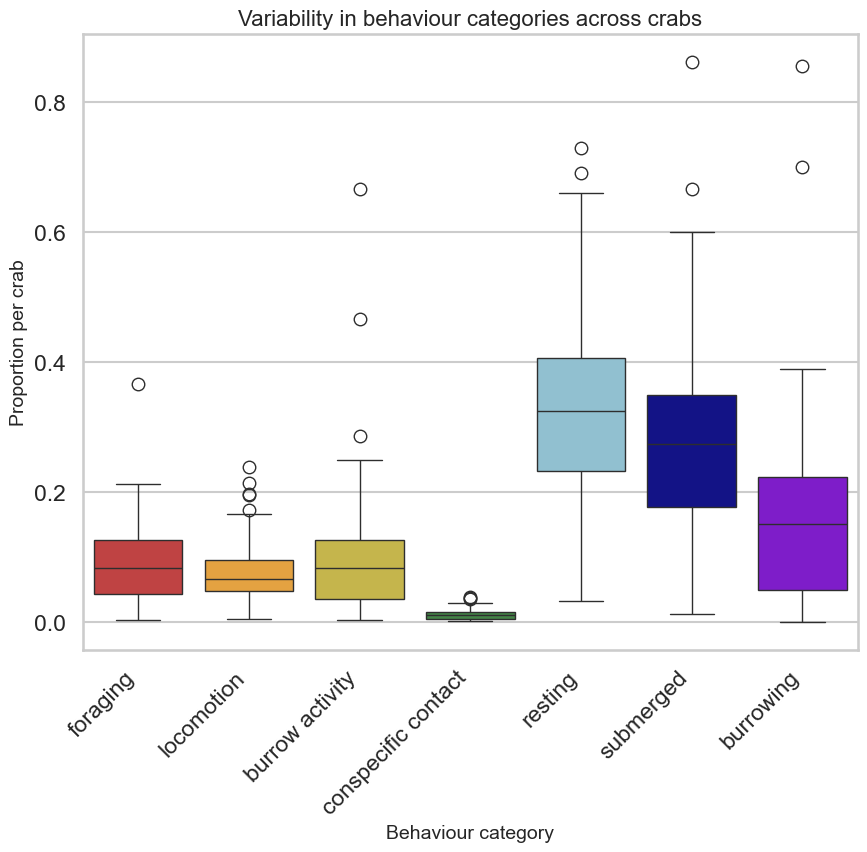

C:\Users\Sanna\AppData\Local\Temp\ipykernel_37164\1763988093.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_proportions.groupby('behaviour_category')['proportion']
C:\Users\Sanna\AppData\Local\Temp\ipykernel_37164\1763988093.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_proportions.groupby('behaviour_category')['proportion']


Coefficient of Variation (%) for each behavioural category:
                     coefficient_of_variation
behaviour_category                           
foraging                            69.625729
locomotion                          61.082266
burrow activity                    100.727267
conspecific contact                 69.182223
resting                             46.986219
submerged                           51.159846
burrowing                           90.556302
Coefficient of Variation (%) for each behavioural category:
                     coefficient_of_variation
behaviour_category                           
foraging                            69.625729
locomotion                          61.082266
burrow activity                    100.727267
conspecific contact                 69.182223
resting                             46.986219
submerged                           51.159846
burrowing                           90.556302


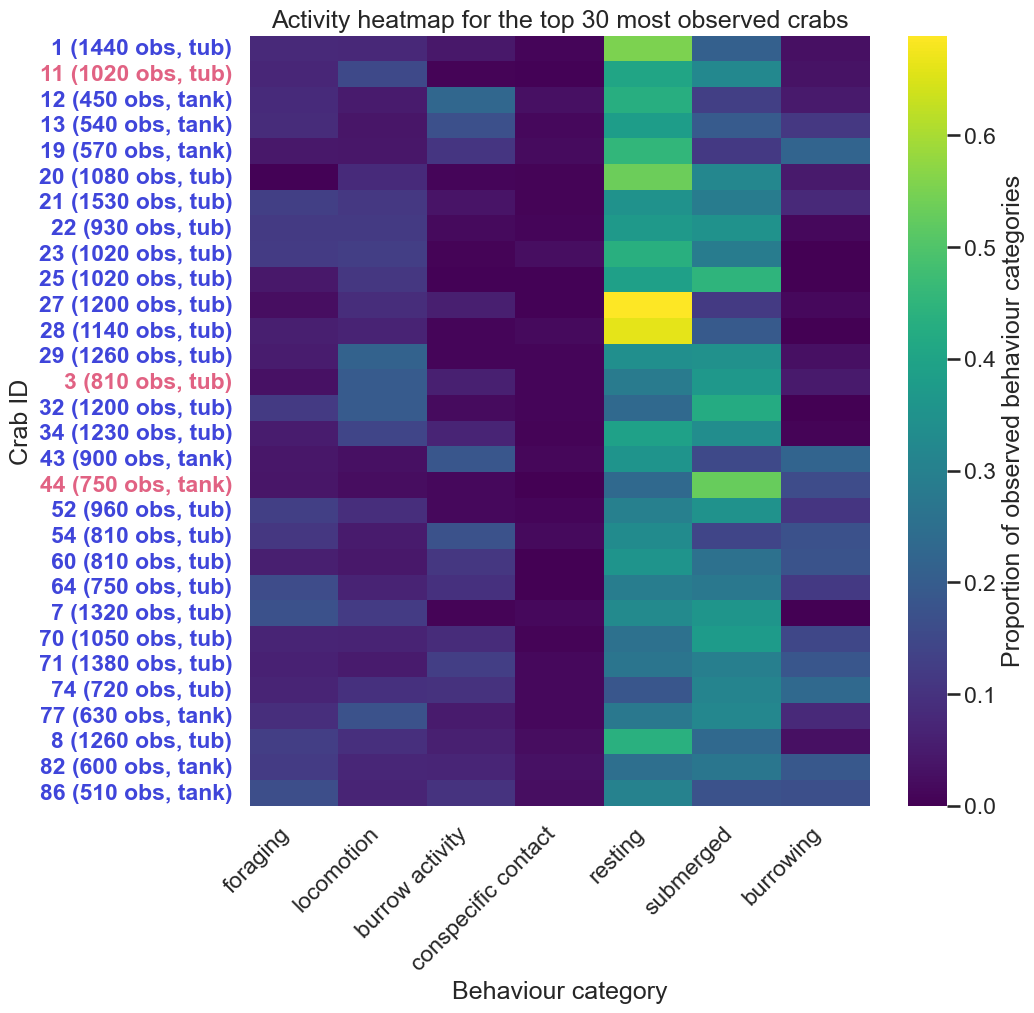

In [53]:
# Figure 2 - Variation
## Figure 2AA - boxplot of behavioural category variation
df_proportions = df_active.groupby(['crab ID', 'behaviour_category']).size().reset_index(name='count')
#(~df_active['behaviour_category'].isin(['conspecific communication', 'conspecific contact']))]
#df_proportions = df_proportions[~df_proportions['behaviour_category'].isin(['conspecific communication', 'conspecific contact'])] # ignoring any behaviour categories that comprise <1% of the activity budget (i.e., conspecific communication. conspecific contact = 6% of all instantaneous behaviours exhibited, on average)
df_proportions['proportion'] = df_proportions.groupby('crab ID')['count'].transform(lambda x: x / x.sum())
filtered_behaviour_category_order = [cat for cat in behaviour_category_order if cat in df_proportions['behaviour_category'].unique()]
df_proportions['behaviour_category'] = pd.Categorical(df_proportions['behaviour_category'], categories=filtered_behaviour_category_order, ordered=True)
filtered_colors = {k: v for k, v in active_category_colors.items() if k in df_proportions['behaviour_category'].unique()}

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
ax = sns.boxplot(data=df_proportions, x='behaviour_category', y='proportion', palette=filtered_colors)

plt.xlabel("Behaviour category", fontsize=14)
ax.set_xticklabels(filtered_behaviour_category_order, rotation=45, ha='right')
for label in ax.get_xticklabels():
    label.set_x(label.get_position()[0] + 0.2)
plt.ylabel("Proportion per crab", fontsize=14)
plt.title("Variability in behaviour categories across crabs", fontsize=16)
plt.savefig(save_path + 'Fig2A_categorical-variability_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

cv_by_category = (
    df_proportions.groupby('behaviour_category')['proportion']
    .agg(['mean', 'std'])
    .assign(coefficient_of_variation=lambda x: (x['std'] / x['mean']) * 100)
)

print("Coefficient of Variation (%) for each behavioural category:")
print(cv_by_category[['coefficient_of_variation']])

#Figure 2B - activity budget heatmap of 30 most observed crabs
## This is a valuble perspective, becuase: 
'''
Method 1 (activity budget): Calculates the proportion over all crabs at once (global proportion).
Method 2 (individual variability): Calculates the proportion for each crab separately, then averages those proportions (mean of individual proportions).
'''

cv_by_category = (
    df_proportions.groupby('behaviour_category')['proportion']
    .agg(['mean', 'std'])
    .assign(coefficient_of_variation=lambda x: (x['std'] / x['mean']) * 100)
)

print("Coefficient of Variation (%) for each behavioural category:")
print(cv_by_category[['coefficient_of_variation']])

df_active["crab ID"] = df_active["crab ID"].astype(str)
df_active["behaviour_category"] = df_active["behaviour_category"].astype(str)

top_crabs = (df_active.groupby("crab ID")[["video file", "tide category"]] 
    .nunique()
    .sum(axis=1)
    .nlargest(30)
    .index)

df_top = df_active[df_active["crab ID"].isin(top_crabs)]
# & (~df_active['behaviour_category'].isin(['conspecific communication', 'conspecific contact']))] # ignoring any behaviour categories that comprise <1% of the activity budget (i.e., conspecific communication. conspecific contact = 6% of all instantaneous behaviours exhibited, on average)
filtered_behaviour_category_order = [cat for cat in behaviour_category_order if cat in df_top['behaviour_category'].unique()]
df_behaviour = (df_top.groupby(["crab ID", "behaviour_category"]).size().unstack(fill_value=0))

df_behaviour = df_behaviour.div(df_behaviour.sum(axis=1), axis=0)
df_behaviour = df_behaviour[filtered_behaviour_category_order]
df_behaviour = df_behaviour.loc[:, df_behaviour.columns]

crab_sex = df_active.set_index("crab ID")["sex"].to_dict()
obs_counts = df_top.groupby("crab ID").size()

crabitats = (
    df_top.groupby("crab ID")["crabitat"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
)

df_behaviour = (df_top.groupby(["crab ID", "behaviour_category"]).size().unstack(fill_value=0))
df_behaviour = df_behaviour.div(df_behaviour.sum(axis=1), axis=0)
df_behaviour = df_behaviour[filtered_behaviour_category_order]
df_behaviour = df_behaviour.loc[:, df_behaviour.columns]

plt.figure(figsize=(10, 10))
ax = sns.heatmap(df_behaviour, cmap="viridis", cbar_kws={'label': 'Proportion of observed behaviour categories'}) 
plt.yticks(rotation=0)
ax.set_xticklabels(filtered_behaviour_category_order, rotation=45, ha='right')
for label in ax.get_xticklabels():
    label.set_x(label.get_position()[0] + 0.2)
    
yticklabels = []
for crab_id in df_behaviour.index:  # crab order from heatmap rows
    n_obs = obs_counts.get(crab_id, 0)
    habitat = crabitats.get(crab_id, "Unknown")
    label = f"{crab_id} ({n_obs} obs, {habitat})"
    yticklabels.append(label)

ax.set_yticklabels(yticklabels)

for label, crab_id in zip(ax.get_yticklabels(), df_behaviour.index):
    sex = crab_sex.get(crab_id, "Unknown")
    color = "#e16283" if sex == "f" else "#3f45da" if sex == "m" else "black"
    label.set_color(color)
    label.set_weight("bold")

plt.xlabel("Behaviour category")
plt.ylabel("Crab ID")
plt.title("Activity heatmap for the top 30 most observed crabs")
plt.savefig(save_path + 'Fig2B_categorical-variation-top30.png', dpi=300, bbox_inches='tight')
plt.show()


Hours present: [20. 21. 12. 13. 19. 15. 22. 11. 17. 18. 10.  9. 14. 16.  8.]
final frame:                attacking burrow  bubbling  burrowing  defending burrow  \
crabitat hour                                                            
tank     0.0           0.100000  0.100000   0.100000          0.100000   
         1.0           0.100000  0.100000   0.100000          0.100000   
         2.0           0.100000  0.100000   0.100000          0.100000   
         3.0           0.100000  0.100000   0.100000          0.100000   
         4.0           0.100000  0.100000   0.100000          0.100000   
         5.0           0.100000  0.100000   0.100000          0.100000   
         6.0           0.100000  0.100000   0.100000          0.100000   
         7.0           0.100000  0.100000   0.100000          0.100000   
         8.0           0.487805  0.000000  31.707317          0.487805   
         9.0           0.000000  0.000000  13.910761          0.000000   
         10.0         

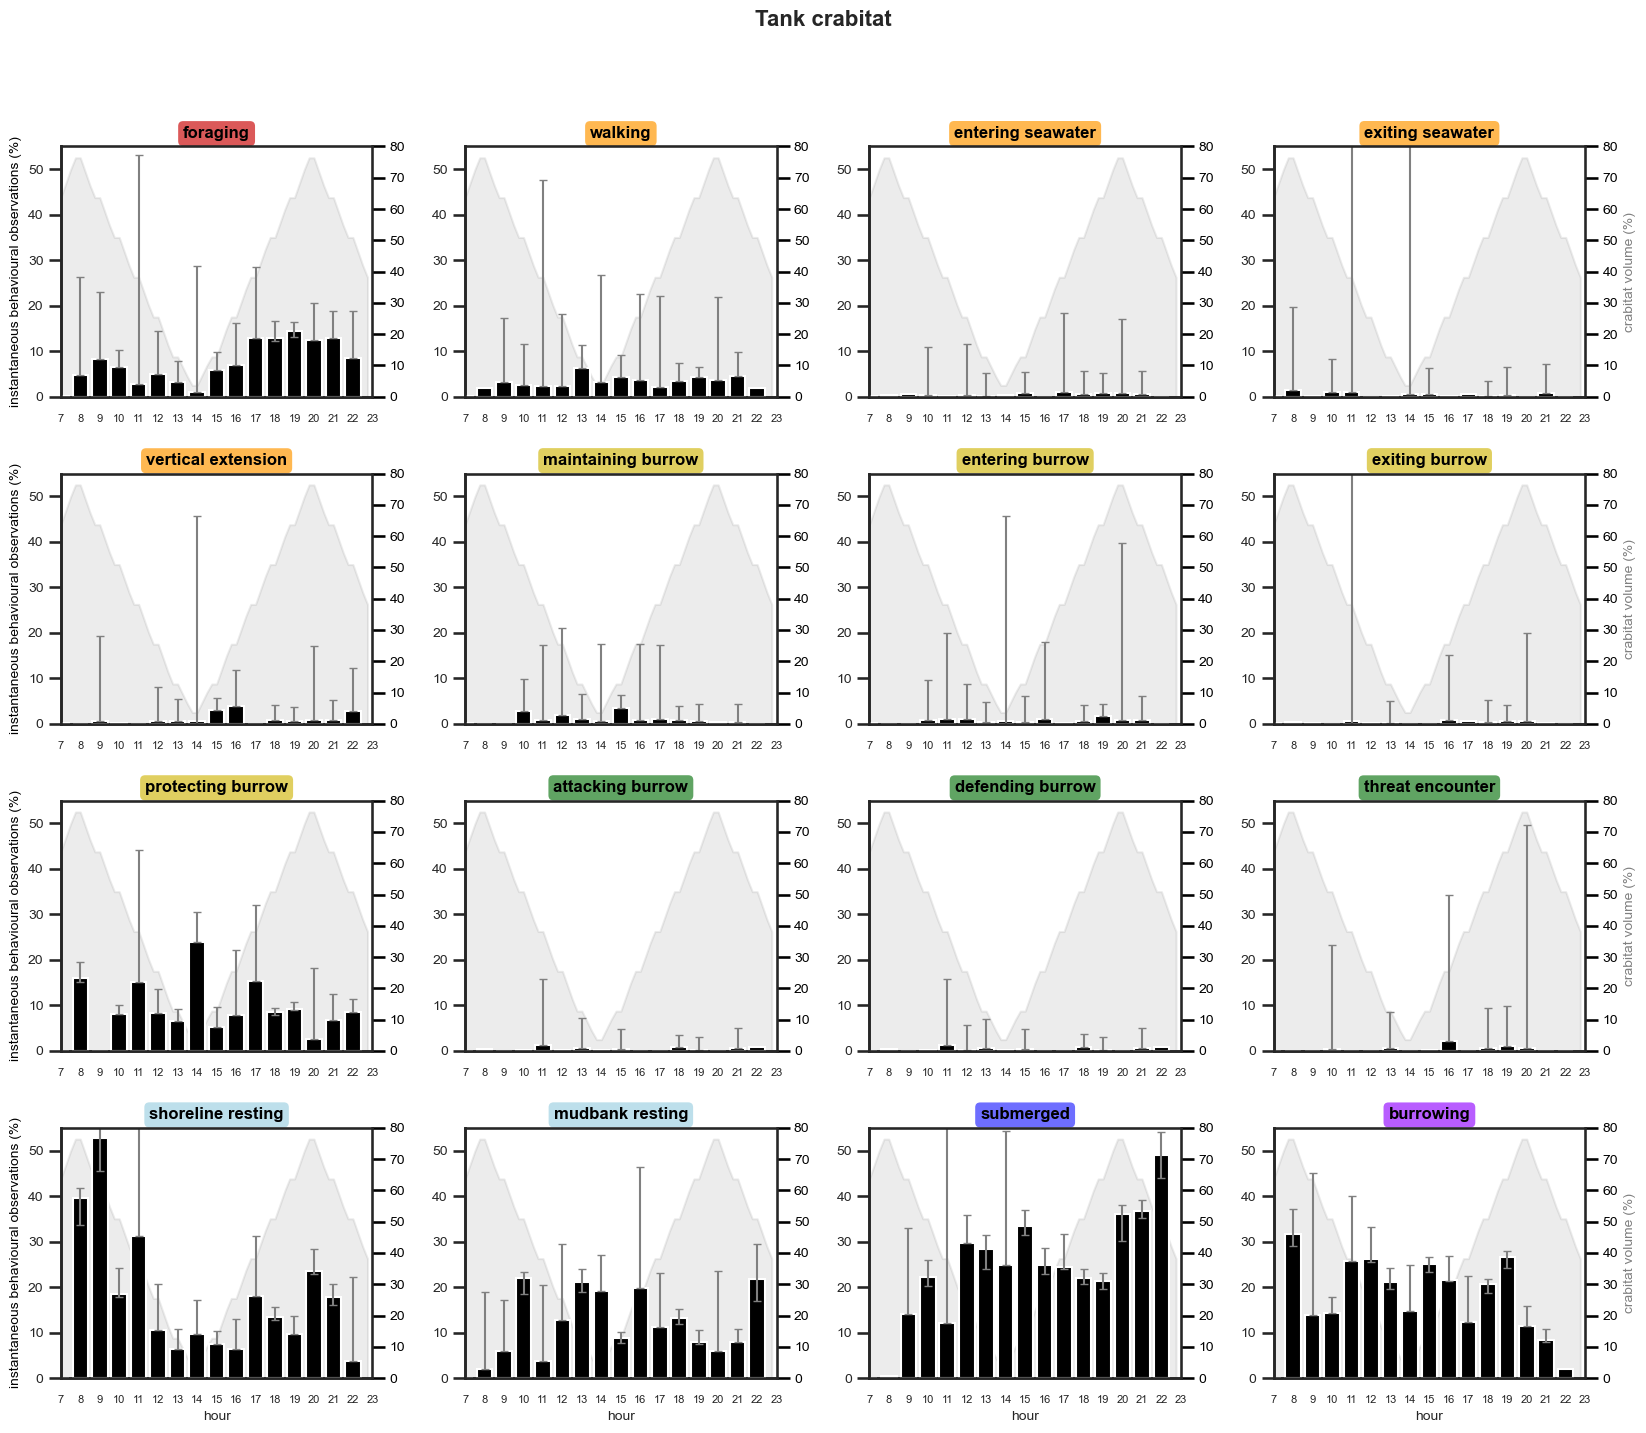

    hour instantaneous behaviour    percent
0    0.0                foraging   0.100000
1    1.0                foraging   0.100000
2    2.0                foraging   0.100000
3    3.0                foraging   0.100000
4    4.0                foraging   0.100000
5    5.0                foraging   0.100000
6    6.0                foraging   0.100000
7    7.0                foraging   0.100000
8    8.0                foraging   4.095004
9    9.0                foraging   3.789004
10  10.0                foraging   1.061008
11  11.0                foraging   1.977401
12  12.0                foraging   4.463415
13  13.0                foraging   2.130682
14  14.0                foraging  10.365854
15  15.0                foraging  12.108758
16  16.0                foraging   9.386617
17  17.0                foraging  16.425756
18  18.0                foraging   8.755896
19  19.0                foraging   6.932953


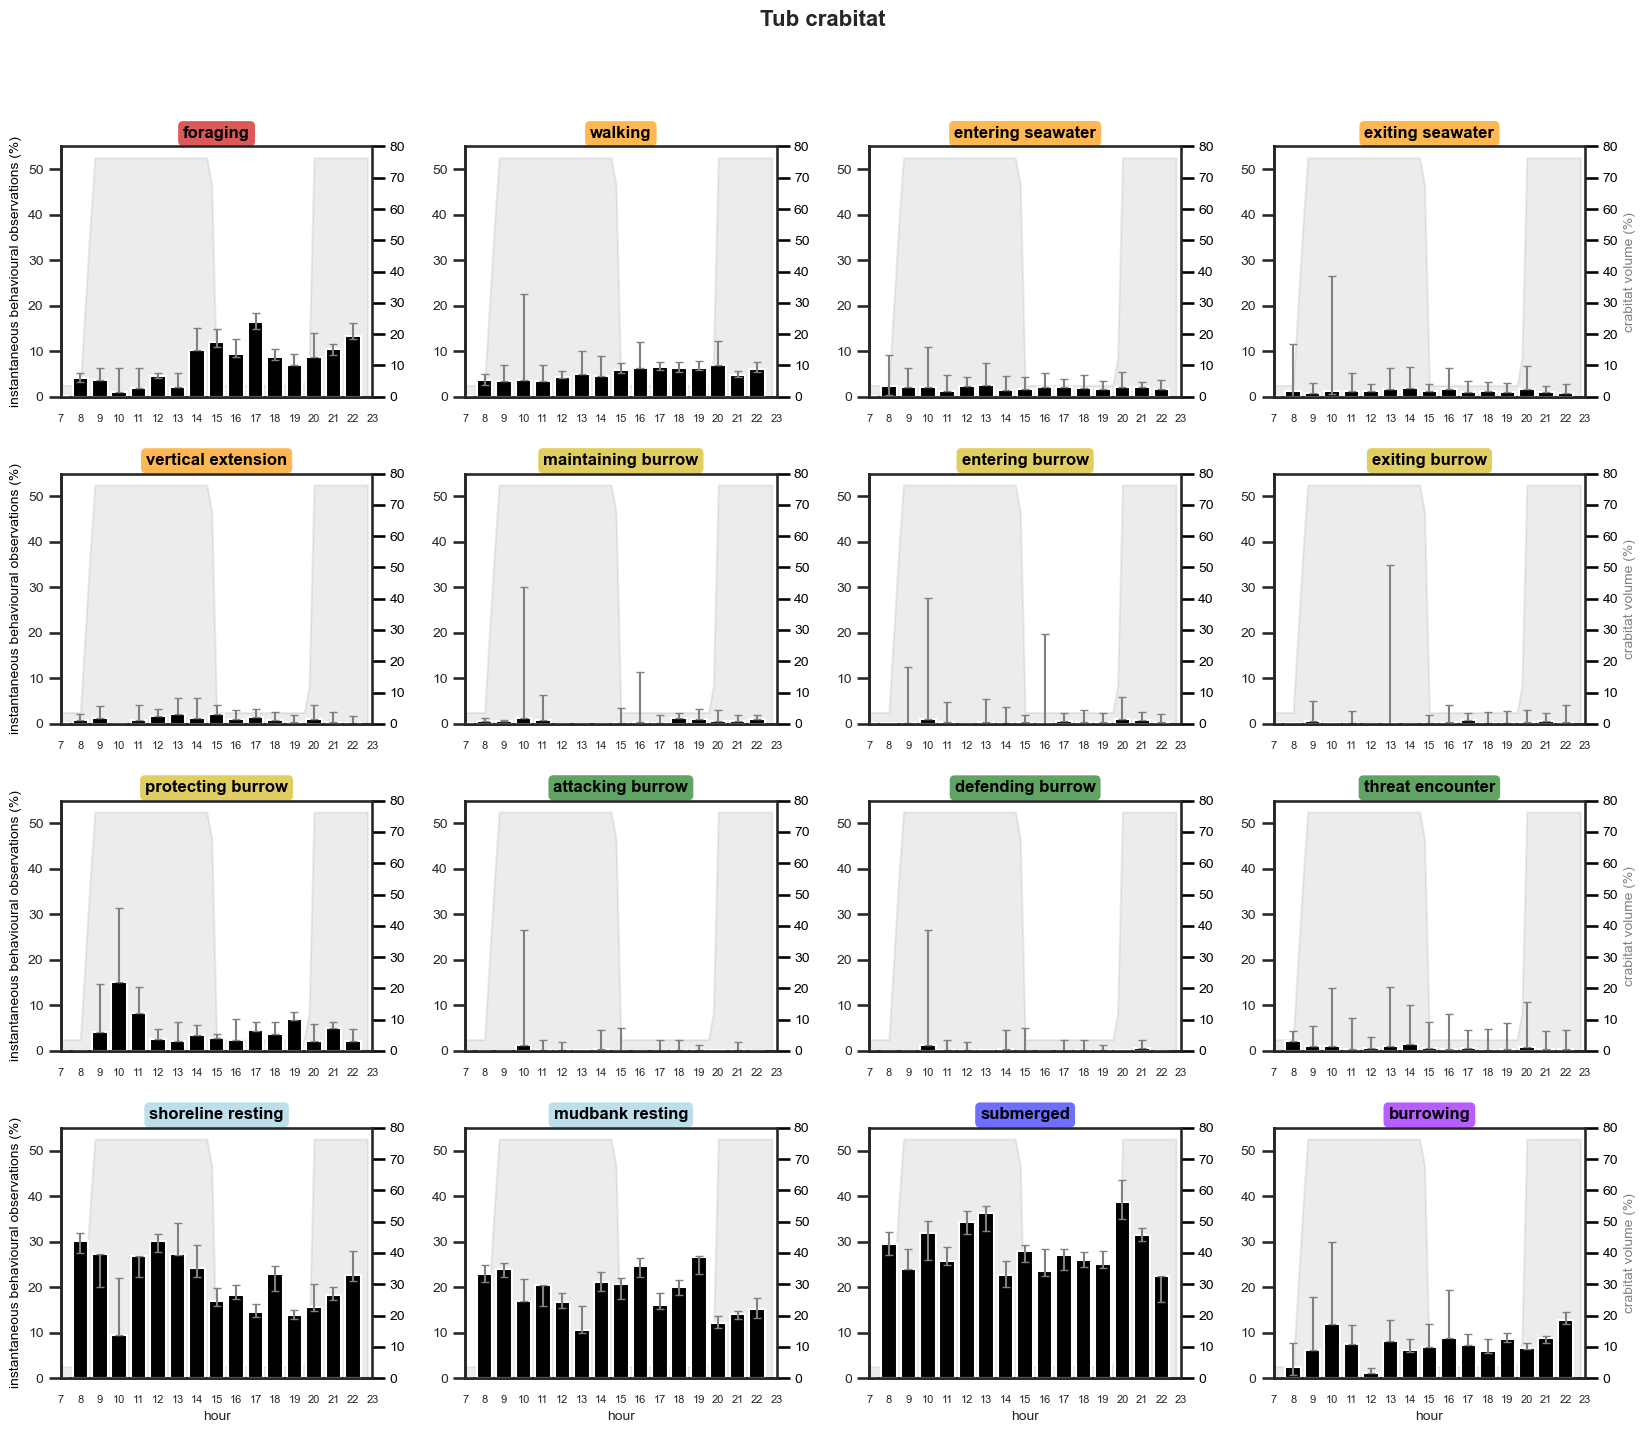

In [54]:
# Figure 3 - facet actogram of instantaneous behaviours per crabitat . 
## Figure 3A = tank, Figure 3B = tub 

# Error metric options:  'std' (standard deviation), 'sem' (standard error), 'ci' (95% confidence interval), 'range' (min-max range), or 'iqr' (interquartile range)

ERROR_METRIC = 'ci'  # Using 95% confidence interval

def calculate_error_bars(df, group_cols, value_col, error_type='sem'):
    """Calculate different types of error metrics"""
    if error_type == 'std':
        return df.groupby(group_cols)[value_col].agg(
            error_lower=lambda x: np.mean(x) - np.std(x, ddof=1),
            error_upper=lambda x: np.mean(x) + np.std(x, ddof=1)
        ).reset_index()
    elif error_type == 'sem':
        return df.groupby(group_cols)[value_col].agg(
            error_lower=lambda x: np.mean(x) - (np.std(x, ddof=1) / np.sqrt(len(x))),
            error_upper=lambda x: np.mean(x) + (np.std(x, ddof=1) / np.sqrt(len(x)))
        ).reset_index()
    elif error_type == 'ci':
        return df.groupby(group_cols)[value_col].agg(
            error_lower=lambda x: np.mean(x) - (1.96 * np.std(x, ddof=1) / np.sqrt(len(x))),
            error_upper=lambda x: np.mean(x) + (1.96 * np.std(x, ddof=1) / np.sqrt(len(x)))
        ).reset_index()
    elif error_type == 'range':
        return df.groupby(group_cols)[value_col].agg(
            error_lower=lambda x: np.min(x),
            error_upper=lambda x: np.max(x)
        ).reset_index()
    elif error_type == 'iqr':
        return df.groupby(group_cols)[value_col].agg(
            error_lower=lambda x: np.percentile(x, 25),
            error_upper=lambda x: np.percentile(x, 75)
        ).reset_index()
    else:
        raise ValueError(f"Unknown error type: {error_type}")

behav = active_instant_order

## tidal and photoperiod regimes extracted from husbandry database 
### normalisation function
def normalize_tide(tide_dict, label):
    df = pd.DataFrame(tide_dict)
    df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S')
    min_vol = df.iloc[:, 1].min()
    max_vol = df.iloc[:, 1].max()
    # Normalize to fit between 0 and 40% for behavioural observations
    df['Normalized'] = ((df.iloc[:, 1] - min_vol) / (max_vol - min_vol)) * 52.5  # Scaling to 0-55
    df['Normalized'] = df['Normalized'].clip(lower=2.5)
    df['Hour'] = df['Time'].dt.hour + df['Time'].dt.minute / 60
    df['Crabitat'] = label
    # Interpolate across all hours from 6 to 22
    all_hours = np.arange(6, 23, 0.25)
    interp = np.interp(all_hours, df['Hour'], df['Normalized'])
    df_interp = pd.DataFrame({'Hour': all_hours, 'Normalized': interp, 'Crabitat': label})
    return df_interp

glass_data = {
    "Time": ["00:00:00", "00:43:00", "01:00:00", "01:43:00", "02:00:00", "02:43:00", "03:00:00", "03:43:00",
        "04:00:00", "04:43:00", "05:00:00", "05:43:00", "06:00:00", "06:43:00", "07:00:00", "07:43:00",
        "08:00:00", "08:43:00", "09:00:00", "09:43:00", "10:00:00", "10:43:00", "11:00:00", "11:43:00",
        "12:00:00", "12:43:00", "13:00:00", "13:43:00", "14:00:00", "14:43:00", "15:00:00", "15:43:00",
        "16:00:00", "16:43:00", "17:00:00", "17:43:00", "18:00:00", "18:43:00", "19:00:00", "19:43:00",
        "20:00:00", "20:43:00", "21:00:00", "21:43:00", "22:00:00", "22:43:00", "23:00:00", "23:43:00"],  # Insert your time list
    "Glass crabitat seawater volume (L)": [
        16.2, 12.6, 12.6, 9, 9, 12.6, 12.6, 16.2, 16.2, 19.8, 19.8, 23.4, 23.4, 27, 27, 30.6, 30.6, 27, 27, 23.4,
        23.4, 19.8, 19.8, 16.2, 16.2, 12.6, 12.6, 9, 9, 12.6, 12.6, 16.2, 16.2, 19.8, 19.8, 23.4, 23.4, 27, 27, 30.6,
        30.6, 27, 27, 23.4, 23.4, 19.8, 19.8, 16.2]
}
tub_data = {
    "Time": glass_data["Time"],
    "Tub crabitat seawater volume (L)": [
        95, 95, 95, 95, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95,
        65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 95, 95, 95, 95, 95, 95, 95, 95
    ]
}
df_tide_glass = normalize_tide(glass_data, 'tank')
df_tide_tub = normalize_tide(tub_data, 'tub')

df_active['real time'] = df_active['real time'].apply(
    lambda t: pd.to_datetime(f'2000-01-01 {t}') if pd.notnull(t) else pd.NaT
)

df_behav = df_active.copy()

df_behav['hour'] = df_behav['real time'].dt.round('h').dt.hour
df_behav['hour'] = df_behav['hour'].astype(float)
print("Hours present:", df_behav['hour'].unique())
#print(df_behav['instantaneous behaviour'].unique())

behaviour_counts = (
    df_behav
    .groupby(['crabitat', 'hour', 'instantaneous behaviour'])
    .size()
    .reset_index(name='count')
)

behaviour_pivot = behaviour_counts.pivot_table(
    index=['crabitat', 'hour'],
    columns='instantaneous behaviour',
    values='count',
    fill_value=0
)

behaviour_percent = behaviour_pivot.div(behaviour_pivot.sum(axis=1), axis=0) * 100
behaviour_percent_reset = behaviour_percent.reset_index()

if 'session_id' not in df_behav.columns:
    df_behav['session_id'] = df_behav.groupby(['real time']).ngroup()

session_counts = (
    df_behav
    .groupby(['crabitat', 'hour', 'session_id', 'instantaneous behaviour'])
    .size()
    .reset_index(name='count')
)

session_totals = (
    session_counts
    .groupby(['crabitat', 'hour', 'session_id'])['count']
    .sum()
    .reset_index(name='total')
)

session_with_totals = pd.merge(
    session_counts, 
    session_totals,
    on=['crabitat', 'hour', 'session_id']
)
session_with_totals['percent'] = (session_with_totals['count'] / session_with_totals['total']) * 100

error_metrics = calculate_error_bars(
    session_with_totals,
    ['crabitat', 'hour', 'instantaneous behaviour'],
    'percent',
    ERROR_METRIC
)

error_lower_wide = error_metrics.pivot_table(
    index=['crabitat', 'hour'],
    columns='instantaneous behaviour',
    values='error_lower'
).fillna(0)

error_upper_wide = error_metrics.pivot_table(
    index=['crabitat', 'hour'],
    columns='instantaneous behaviour',
    values='error_upper'
).fillna(0)

error_lower_reset = error_lower_wide.reset_index()
error_upper_reset = error_upper_wide.reset_index()

missing_hours = pd.DataFrame(
    [(crabitat, hour) for crabitat in behaviour_percent_reset['crabitat'].unique()
                         for hour in range(0, 8)],
    columns=['crabitat', 'hour']
)

placeholder_values = missing_hours.copy()
for col in behaviour_percent_reset.columns[2:]: 
    placeholder_values[col] = 0.1
placeholder_values.set_index(['crabitat', 'hour'], inplace=True)

behaviour_percent_full = pd.concat([behaviour_percent, placeholder_values])
behaviour_percent_full = behaviour_percent_full.sort_index()
print('final frame:', behaviour_percent_full)

df_merged = behaviour_percent_full
df_merged_reset = df_merged.reset_index()
print("Hours present:", df_behav['hour'].unique())
print(df_behav['instantaneous behaviour'].unique())

def plot_facet_for_crabitat(crabitat, tide_df):
    data = df_merged_reset[df_merged_reset['crabitat'] == crabitat].copy()

    cols_to_keep = ['crabitat', 'hour'] + behav
    data = data[cols_to_keep]
    
    data_melted = data.melt(
        id_vars=['hour', 'crabitat'], 
        value_vars=behav, 
        var_name='instantaneous behaviour', 
        value_name='percent'
    )
    
    data_melted['instantaneous behaviour'] = pd.Categorical(
        data_melted['instantaneous behaviour'], categories=behav, ordered=True
    )
    data_melted.sort_values(['instantaneous behaviour', 'hour'], inplace=True)
    
    print(data_melted[['hour', 'instantaneous behaviour', 'percent']].head(20))
    
    sns.set(style="white", context="talk") 
    g = sns.FacetGrid(
        data_melted, col='instantaneous behaviour', col_wrap=4,
        height=3.5, aspect=1.2, sharex=False, sharey=False
    )
    
    def barplot_with_tide(data, **kwargs):
        ax = plt.gca()
        tide = tide_df.copy()
        
        ax.grid(False)
        
        data = data.copy()
        
        current_behaviour = data['instantaneous behaviour'].iloc[0]
        current_crabitat = data['crabitat'].iloc[0]
        
        tide = tide[(tide['Hour'] >= 7) & (tide['Hour'] <= 23)]
        ax.fill_between(tide['Hour'], tide['Normalized'], alpha=0.15, color='grey', zorder=0)
        
        pivot_data = data.pivot_table(index='hour', values='percent', aggfunc='mean')
        
        lower_bounds = error_lower_reset[
            (error_lower_reset['crabitat'] == current_crabitat)
        ].set_index('hour')
        
        upper_bounds = error_upper_reset[
            (error_upper_reset['crabitat'] == current_crabitat)
        ].set_index('hour')
        
        bars = ax.bar(
            pivot_data.index, 
            pivot_data['percent'],
            color='black', 
            zorder=10
        )
        
        if current_behaviour in lower_bounds.columns and current_behaviour in upper_bounds.columns:
            for i, (hour, row) in enumerate(pivot_data.iterrows()):
                mean_val = row['percent']
                
                if hour in lower_bounds.index:
                    lower_val = lower_bounds.at[hour, current_behaviour]
                    upper_val = upper_bounds.at[hour, current_behaviour]
                    
                    if lower_val <= upper_val and not np.isclose(lower_val, upper_val):
                        yerr_lower = max(0, mean_val - lower_val)  
                        yerr_upper = max(0, upper_val - mean_val)
                        
                        ax.errorbar(
                            x=hour,
                            y=mean_val,
                            yerr=[[yerr_lower], [yerr_upper]],
                            fmt='none',
                            ecolor='grey',
                            elinewidth=1.5,
                            capsize=3,
                            zorder=15
                        )
        
        ax.set_xlim(8, 23)
        ax.set_xticks(range(8, 23, 1)) 
        ax.set_xticklabels([str(h) for h in range(8, 23)])
        ax.tick_params(axis='x', rotation=0)
        ax.tick_params(axis='x', labelsize=10)  
        ax.tick_params(axis='y', labelsize=10) 

        # tide axis 
        ax2 = ax.twinx()
        ax2.set_ylim(0, 80)
        ax2.grid(False)
        
        ax2.tick_params(axis='y', labelsize=10, colors='black')
        
        # place the "crabitat volume (%)" label once for each row of facets
        if ax == g.axes[3]: 
            ax2.set_ylabel("crabitat volume (%)", color='grey', size=10)
        if ax == g.axes[7]:  
            ax2.set_ylabel("crabitat volume (%)", color='grey', size=10)
        if ax == g.axes[11]:
            ax2.set_ylabel("crabitat volume (%)", color='grey', size=10)
        if ax == g.axes[15]:  
            ax2.set_ylabel("crabitat volume (%)", color='grey', size=10)
        
        ax.set_ylim(0, 55)  
        ax.set_ylabel("instantaneous behavioural observations (%)", color='black')
    
    g.map_dataframe(barplot_with_tide)
    
    def get_category_color(col_name):
        category = active_behaviour_category.get(col_name, None)
        return facet_category_colors.get(category, 'black')  

    g.set_titles(col_template="{col_name}", size=10)
    for ax in g.axes.flat:
        col_name = ax.get_title()
        color = get_category_color(col_name)
        ax.set_title(
            col_name,
            color='black',
            fontsize=12,
            weight='bold',
            bbox=dict(
                facecolor=color,
                edgecolor='none',
                boxstyle='round,pad=0.3',
                alpha=0.8 
            )
        )
    
    g.set_axis_labels("hour", "instantaneous behavioural observations (%)")
    
    for ax in g.axes.flatten():
        ax.yaxis.label.set_size(10)
        ax.xaxis.label.set_size(10)
    
    g.fig.suptitle(f"{crabitat.capitalize()} crabitat", y=1.03, fontsize=16, weight='bold')
    
    g.fig.subplots_adjust(hspace=0.5)  
    plt.tight_layout()
    
    for ax in g.axes.flat:
        ax.set_xticks(range(7, 24, 1)) 
        ax.set_xticklabels([str(h) for h in range(7, 24)])
        ax.tick_params(axis='x', labelsize=8)
    
    plt.show()

    return g

tank_grid = plot_facet_for_crabitat('tank', df_tide_glass)
tank_grid.fig.savefig(save_path + 'Fig3A_instantaneous-facet-actogram-tank.png', dpi=900, bbox_inches='tight')

tub_grid = plot_facet_for_crabitat('tub', df_tide_tub)
tub_grid.fig.savefig(save_path + 'Fig3B_instantaneous-facet-actogram-tub.png', dpi=900, bbox_inches='tight')

c:\Users\Sanna\miniconda3\envs\activity-buget_analysis_mc-2\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


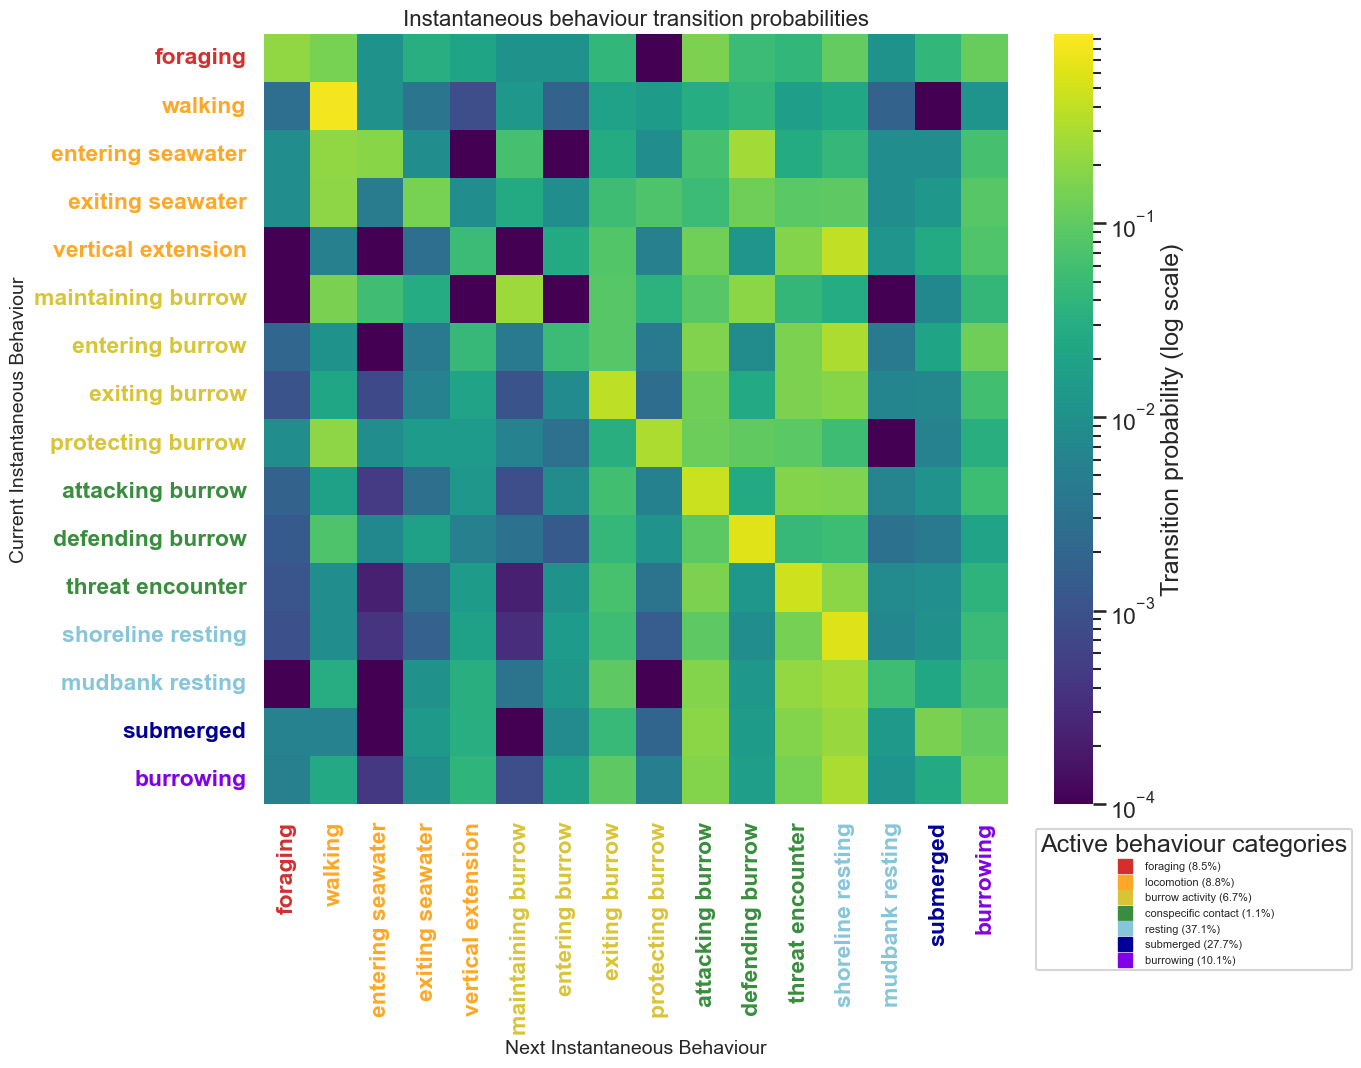

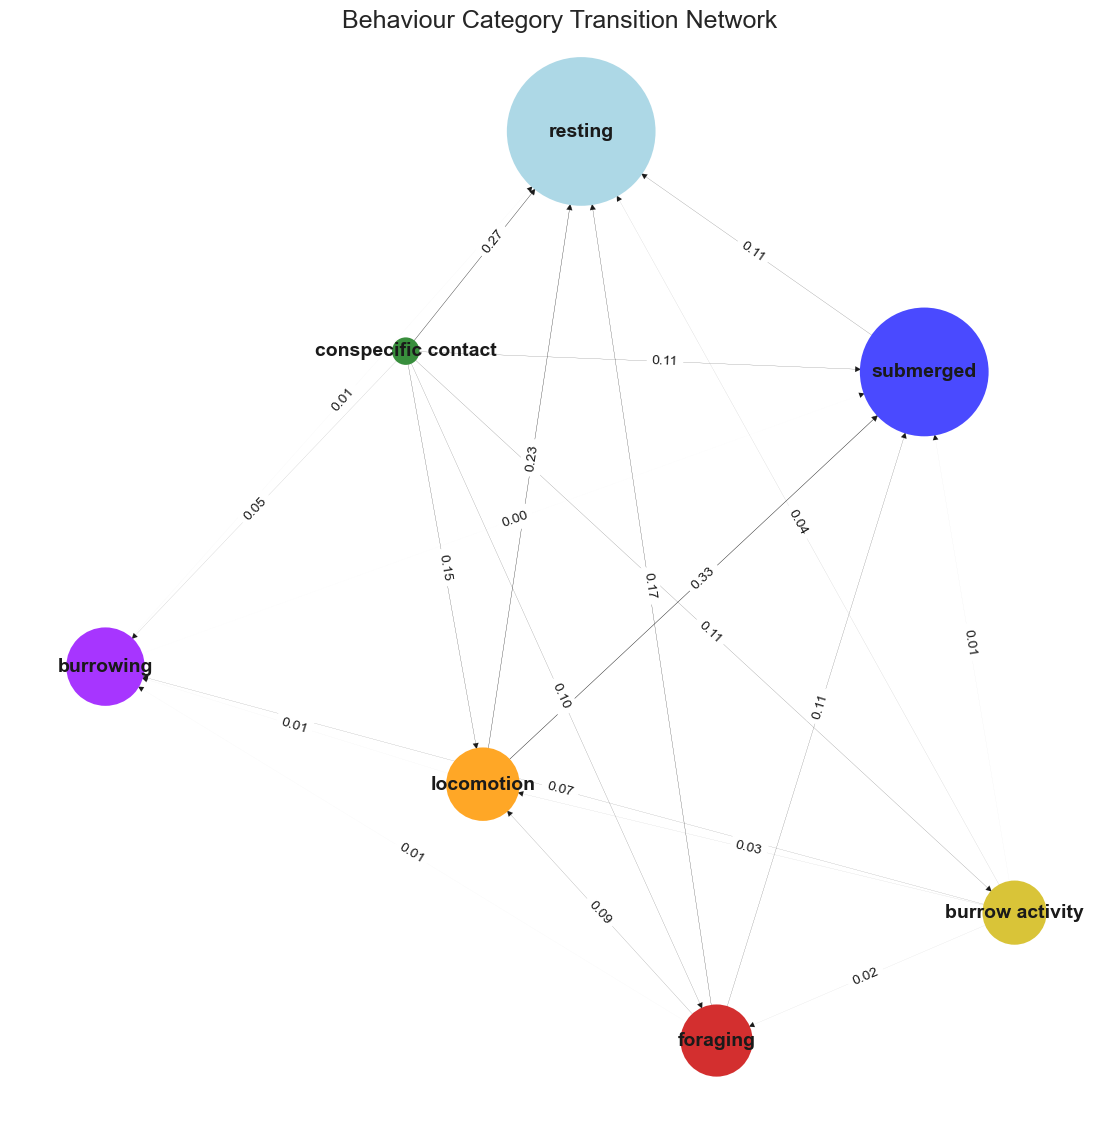

In [55]:
# Figure 4A Instantaneous transition heatmap

df_active['behaviour_category'] = df_active['instantaneous behaviour'].map(behaviour_category)
df_transitions = df_active.copy()
#df['observation time'] = pd.to_datetime(df['real time'])
df = df_transitions.sort_values(by=['crab ID', 'video file', 'tide category', 'observation minute from start'])
df['next behaviour'] = df_transitions.groupby(['crab ID', 'video file', 'tide category'])['behaviour_category'].shift(-1)
transitions = df[['behaviour_category', 'next behaviour']].dropna()
transition_counts = transitions.groupby(['behaviour_category', 'next behaviour']).size().reset_index(name='count')
transition_matrix = transition_counts.pivot(index='behaviour_category', columns='next behaviour', values='count').fillna(0)
transition_matrix_prob_cat = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)

df_transitions = df_active.copy()

excluded_behaviours = ['tapping', 'waving', 'moulting', 'mating', 'bubbling', 'putative sleep']
df_transitions = df_transitions[~df_transitions['instantaneous behaviour'].isin(excluded_behaviours)]

df = df_transitions.sort_values(by=['crab ID', 'video file', 'tide category', 'observation minute from start'])
df['next behaviour'] = df_transitions.groupby(['crab ID', 'video file', 'tide category'])['instantaneous behaviour'].shift(-1)

df = df_transitions.sort_values(by=['crab ID', 'video file', 'tide category', 'observation minute from start'])
df['next behaviour'] = df.groupby(['crab ID', 'video file', 'tide category'])['instantaneous behaviour'].shift(-1)

transitions = df[['instantaneous behaviour', 'next behaviour']].dropna()
transitions = transitions[
    (~transitions['instantaneous behaviour'].isin(excluded_behaviours)) &
    (~transitions['next behaviour'].isin(excluded_behaviours))
]

transitions = df[['instantaneous behaviour', 'next behaviour']].dropna()
transition_counts = transitions.groupby(['instantaneous behaviour', 'next behaviour']).size().reset_index(name='count')
transition_matrix = transition_counts.pivot(index='instantaneous behaviour', columns='next behaviour', values='count').fillna(0)
transition_matrix_prob = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)
melted = transition_matrix_prob.reset_index().melt(id_vars='instantaneous behaviour', var_name='next behaviour', value_name='probability')
melted = melted[melted['probability'] > 0] 

kmeans = KMeans(n_clusters=2, random_state=42)
melted['Cluster'] = kmeans.fit_predict(melted[['probability']])
label_encoder = LabelEncoder()
melted['current_behaviour_numeric'] = melted['instantaneous behaviour'].map(lambda x: active_instant_order.index(x))
melted['next_behaviour_numeric'] = melted['next behaviour'].map(lambda x: active_instant_order.index(x))

categories_used = {active_behaviour_category[beh] for beh in active_instant_order if beh in active_behaviour_category}

categories_sorted = [cat for cat in active_behaviour_category_order if cat in categories_used]

handles_active = [
    Line2D([0], [0], color=active_category_colors[cat], marker='s', linestyle='None', markersize=10)
    for cat in categories_sorted
]

transition_matrix_prob_no_zeros = transition_matrix_prob.replace(0, 0.0001)

active_instant_order_filtered = [b for b in active_instant_order if b not in excluded_behaviours]

plt.figure(figsize=(12, 10))

heatmap = sns.heatmap(
    transition_matrix_prob_no_zeros,
    annot=False,
    cmap='viridis',
    cbar_kws={'label': 'Transition probability (log scale)'},
    xticklabels=active_instant_order_filtered,
    yticklabels=active_instant_order_filtered,
    norm=LogNorm(vmin=0.0001, vmax=0.95)
)

ax = plt.gca()

for tick_label in ax.get_xticklabels():
    behaviour = tick_label.get_text()
    category = behaviour_category.get(behaviour)
    tick_label.set_color(active_category_colors[category])
    tick_label.set_weight("bold")

for tick_label in ax.get_yticklabels():
    behaviour = tick_label.get_text()
    category = behaviour_category.get(behaviour)
    tick_label.set_color(active_category_colors[category])
    tick_label.set_weight("bold")

plt.title('Instantaneous behaviour transition probabilities', size=16)
plt.xlabel('Next Instantaneous Behaviour', size=14)
plt.ylabel('Current Instantaneous Behaviour', size=14)
plt.legend(handles_active, behaviour_labels_active, title='Active behaviour categories', bbox_to_anchor=(1.03, -0.025), loc='upper left', fontsize=8)
plt.savefig(save_path + 'Fig4A_instantaneous-transition.png', dpi=300, bbox_inches='tight')

plt.show()

# Figure 4B Transition network diagram
## Node size = frequency of observation (activity budget %)
## There are bi-directional transition proportions for every single combination, this graph is only keeping the strongest direction. 
## This is not supposed to have the self-transition loops visible, however the probabilities of these should be listed under the name of each category. If the numbers are not visualising well (or are absent), unhash the G.add_edge (labelled # unhash here), re-run, then re-hash and re-run

G = nx.DiGraph()

for current in transition_matrix_prob_cat.index:
    for next_ in transition_matrix_prob_cat.columns:
        if current != next_:  
            p1 = transition_matrix_prob_cat.loc[current, next_]
            p2 = transition_matrix_prob_cat.loc[next_, current]
            if p1 > p2 and p1 > 0.001:
                G.add_edge(current, next_, weight=p1)
            elif p2 > p1 and p2 > 0.001:
                G.add_edge(next_, current, weight=p2)
        else:
            if transition_matrix_prob_cat.loc[current, next_] > 0.001:  
                placeholder=1
                #G.add_edge(current, next_, weight=transition_matrix_prob_cat.loc[current, next_]) # unhash here, re-run, then re-has and re-run if the self-transition numbers are not showing well (this should make self loops visible for the first run, and replace these with the numbers on the second) 

# Node sizes = time spent in each state (activity budget %)
state_frequencies = df_active['behaviour_category'].value_counts(normalize=True) 
node_sizes = [30000 * state_frequencies.get(n,0) for n in G.nodes()]

node_colors = [facet_category_colors.get(node, '#CCCCCC') for node in G.nodes()]

plt.figure(figsize=(11, 11))
pos = nx.kamada_kawai_layout(G, weight='weight')
pos = nx.spring_layout(G, pos=pos, k=1.75, iterations=50)

for n in G.nodes():
    if (n, n) in labels:
        x, y = pos[n] 
        plt.text(x, y - 0.05, labels[(n, n)], fontsize=12, weight='demibold', ha='center') 
        
nx.draw(G, pos, with_labels=True, node_size=node_sizes, 
        node_color=node_colors, font_size=14, font_weight='bold', 
        arrows=True, width=[1 * G[u][v]['weight'] for u, v in G.edges()])

labels = {(n1, n2): f"{v:.2f}" for n1, n2, v in G.edges(data='weight')}

nx.draw_networkx_edge_labels(G, pos, edge_labels={k: v for k, v in labels.items() if k[0] != k[1]})

## The 0.10 transition probability from submerged -> resting will likely be covered by the foraging node; if required, can add it in post-hoc for visibility 

plt.title('Behaviour Category Transition Network')
plt.savefig(save_path + 'Fig4B_categorical-transition-network.png', dpi=300) # bbox_inches='tight' possible but avoided to fit nodes in 11x11
plt.show()

C:\Users\Sanna\AppData\Local\Temp\ipykernel_37164\2185559609.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  photo_activity_counts = df_active.groupby(['photoperiod', 'behaviour_category']).size().unstack(fill_value=0)
C:\Users\Sanna\AppData\Local\Temp\ipykernel_37164\2185559609.py:52: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  top_pivot = top_counts.pivot_table(


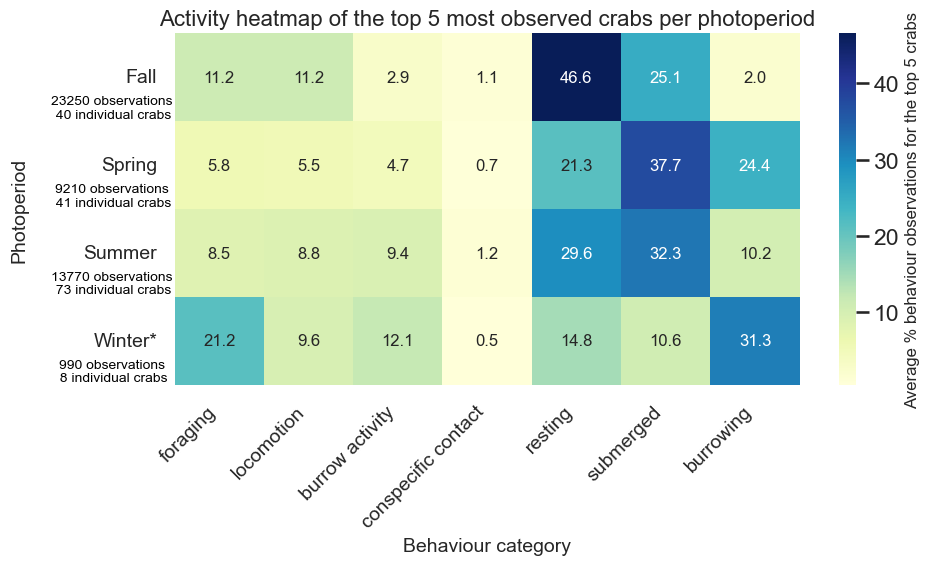

In [56]:
# Figure 5 - Activity heatmap for the top 5 most-observed crabs by photoperiod 

df_active['behaviour_category'] = pd.Categorical(
    df_active['behaviour_category'], 
    categories=active_behaviour_category_order, 
    ordered=True
)

photo_activity_counts = df_active.groupby(['photoperiod', 'behaviour_category']).size().unstack(fill_value=0)
photo_activity_percentage = photo_activity_counts.div(photo_activity_counts.sum(axis=1), axis=0) * 100
photo_activity_percentage = photo_activity_percentage[active_behaviour_category_order]

obs_counts = df_active.groupby('photoperiod').size()
df_active["crab ID"] = df_active["crab ID"].astype(str)
unique_crabs = df_active.groupby('photoperiod')['crab ID'].nunique()

## 1. For each photoperiod, identify the top 5 most observed crabs 2. calculate the proportion of their observations that fall into each behaviour category per crab & then average. 

df_active['behaviour_category'] = pd.Categorical(
    df_active['behaviour_category'], 
    categories=active_behaviour_category_order, 
    ordered=True
)

# Get top 5 crabs *within each photoperiod*
top_crabs_by_period = (
    df_active.groupby(['photoperiod', 'crab ID'], observed=True)
    .size()
    .reset_index(name='obs_count')
    .sort_values(['photoperiod', 'obs_count'], ascending=[True, False])
    .groupby('photoperiod')
    .head(5)
)

df_top = df_active.merge(top_crabs_by_period[['photoperiod', 'crab ID']], on=['photoperiod', 'crab ID'])

top_counts = (
    df_top.groupby(['photoperiod', 'crab ID', 'behaviour_category'], observed=True)
    .size()
    .rename("count")
    .reset_index()
)

top_totals = (
    top_counts
    .groupby(['photoperiod', 'crab ID'], observed=True)['count']
    .transform('sum')
)

top_counts['proportion'] = top_counts['count'] / top_totals

top_pivot = top_counts.pivot_table(
    index=['photoperiod', 'crab ID'],
    columns='behaviour_category',
    values='proportion',
    fill_value=0
)

photo_activity_top5 = top_pivot.groupby('photoperiod').mean() * 100
photo_activity_top5 = photo_activity_top5[active_behaviour_category_order]

plt.figure(figsize=(10, 6))
ax = sns.heatmap(photo_activity_top5, annot=True, fmt=".1f", cmap="YlGnBu",
                 annot_kws={"fontsize": 12},
                 cbar_kws={'label': 'Average % behaviour observations for the top 5 crabs'})

cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel('Average % behaviour observations for the top 5 crabs', fontsize=12)

plt.title('Activity heatmap of the top 5 most observed crabs per photoperiod', fontsize=16)
plt.xlabel('Behaviour category', fontsize=14)
plt.ylabel('Photoperiod', fontsize=14, labelpad=40)

main_labels = photo_activity_percentage.index.tolist()
custom_labels = [label + '*' if label.lower() == 'winter' else label for label in main_labels]
plt.yticks(ticks=np.arange(len(custom_labels)) + 0.5, labels=custom_labels, rotation=0, fontsize=14)

for i, period in enumerate(photo_activity_percentage.index):
    stats_label = f"{obs_counts[period]} observations\n {unique_crabs[period]} individual crabs"
    ax.text(-0.7, i + 0.7, stats_label, fontsize=10, va='top', ha='center', color='black')

plt.xticks(rotation=45, ha='right', fontsize=14)
for label in ax.get_xticklabels():
    label.set_x(label.get_position()[0] + 0.2)

plt.ylim(len(photo_activity_percentage), 0)
plt.tight_layout()
plt.savefig(save_path + 'Fig5_categorical-heatmap-photoperiod.png', dpi=300)
plt.show()